In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from alm.core.cashflow import CashFlow
from alm.core.risk import present_value_at_yield
from alm.applications.rate_tree import (
    RateTree,
    price_bond,
    price_bond_with_option,
)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

## 1. The Recombining Tree

The short rate starts at `r0` and each step moves up (×u) or down (×d). Because `r·u·d = r·d·u`, an up-then-down move lands on the *same* node as down-then-up — the tree **recombines**. This collapses the node count from `2^n` to `(n+1)(n+2)/2`, and lets the whole tree live in a triangular array.

短期利率從 `r0` 出發,每一步向上(×u)或向下(×d)。由於 `r·u·d = r·d·u`,上跳再下跳與下跳再上跳落在**同一**節點——樹會**重合**。這將節點數從 `2^n` 壓縮到 `(n+1)(n+2)/2`,並讓整棵樹存於一個三角陣列中。

In [2]:
# Build a small tree we can inspect by eye.
tree = RateTree(r0=0.05, u=1.15, d=0.87, n_steps=4, p=0.5, dt=1.0)

print(tree)
print(f"\nNode count: {tree.node_count()}  "
      f"(vs. {2**tree.n_steps} for a non-recombining tree)")

# Dense view: rates as percentages, NaN where nodes don't exist.
dense = tree.as_dense() * 100
print("\nShort rates by (step, node), % — upper triangle is empty:\n")
print(np.round(dense, 2))

RateTree(n_steps=4, r0=0.0500, u=1.1500, d=0.8700, p=0.5)

Node count: 15  (vs. 16 for a non-recombining tree)

Short rates by (step, node), % — upper triangle is empty:

[[5.    nan  nan  nan  nan]
 [4.35 5.75  nan  nan  nan]
 [3.78 5.   6.61  nan  nan]
 [3.29 4.35 5.75 7.6   nan]
 [2.86 3.79 5.01 6.62 8.75]]


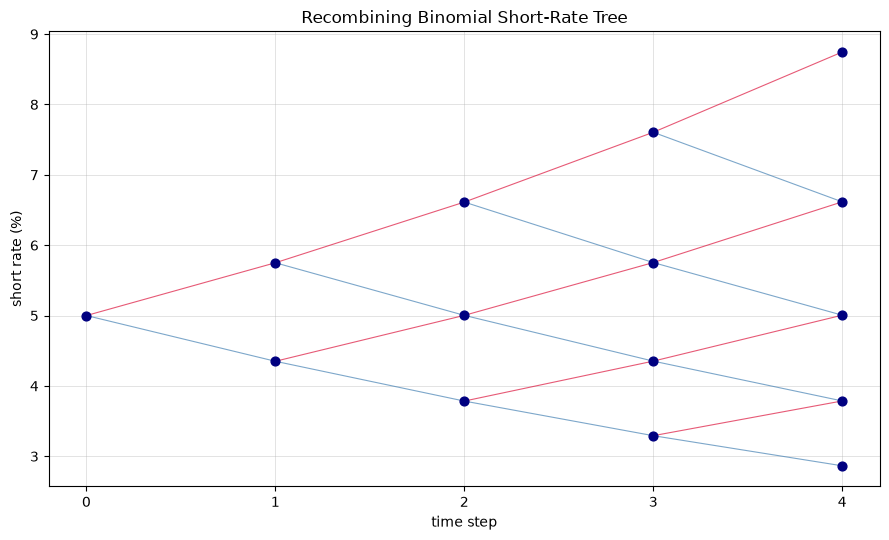

In [3]:
# Plot the tree: each node placed at (step, rate), with up/down edges.
fig, ax = plt.subplots(figsize=(9, 5.5))

for i in range(tree.n_steps + 1):
    for j in range(i + 1):
        r = tree.short_rate(i, j)
        ax.scatter(i, r * 100, color="navy", zorder=5, s=40)
        # Draw edges to the two children (up: j+1, down: j) at step i+1.
        if i < tree.n_steps:
            r_up = tree.short_rate(i + 1, j + 1)
            r_down = tree.short_rate(i + 1, j)
            ax.plot([i, i + 1], [r * 100, r_up * 100],
                    color="crimson", lw=0.8, alpha=0.7)
            ax.plot([i, i + 1], [r * 100, r_down * 100],
                    color="steelblue", lw=0.8, alpha=0.7)

ax.set_xlabel("time step")
ax.set_ylabel("short rate (%)")
ax.set_title("Recombining Binomial Short-Rate Tree")
ax.set_xticks(range(tree.n_steps + 1))

plt.tight_layout()
plt.show()

## 2. Pricing a Plain Bond — and Cross-Checking It

We price a plain coupon bond by **backward induction**: start from the known value at maturity, then fold backward, at each node taking the risk-neutral expected value of its two children and discounting one step at that node's rate. This is a post-order traversal — a node is computed only after its children.

我們以**後序回推**為普通附息債券定價:從到期時的已知價值出發,向後折疊,在每個節點取其兩個子節點的風險中性期望值、並以該節點利率折現一步。這是後序遍歷——節點只在其子節點算完後才計算。

A plain bond has no optionality, so its tree price should match ordinary discounting at the tree's rate. That equality is our correctness check.

普通債券沒有選擇權,所以其樹定價應與在樹利率下的一般折現相符。這個相等關係就是我們的正確性檢驗。

In [4]:
# A 4-year 5% annual coupon bond on 100 face value.
bond = CashFlow(times=[1, 2, 3, 4], amounts=[5, 5, 5, 105])

# Price on a tree whose rates stay very close to a flat 5% (tiny up/down),
# so we have a deterministic price to check against.
flat_tree = RateTree(r0=0.05, u=1.0001, d=0.9999, n_steps=4, p=0.5, dt=1.0)

tree_price = price_bond(bond, flat_tree)
deterministic = present_value_at_yield(bond, 0.05)

print(f"Tree price (backward induction): {tree_price:.6f}")
print(f"Deterministic discounting at 5%: {deterministic:.6f}")
print(f"Difference:                      {abs(tree_price - deterministic):.2e}")

Tree price (backward induction): 99.550603
Deterministic discounting at 5%: 99.550603
Difference:                      1.54e-08


## 3. Embedded Options: Callable and Putable Bonds

Now the payoff. A **callable** bond lets the *issuer* buy it back at a set price — they will when rates fall (the bond has become expensive to them), capping the holder's upside. A **putable** bond lets the *holder* sell it back — they will when rates rise, setting a floor. In backward induction this is a single extra step at each exercisable node:

現在是重點。**可贖回**債券讓*發行方*以約定價買回——利率下跌時他們會這麼做(債券對他們變貴了),從而限制持有人的上檔。**可回售**債券讓*持有人*賣回——利率上升時他們會這麼做,從而設下底限。在後序回推中,這只是每個可行使節點上多一個步驟:

callable: V = min(hold, strike)    putable: V = max(hold, strike)

The whole difference between the two is min vs. max — the same optimal-exercise structure, mirrored by whose option it is.

兩者的全部差異就是 min 與 max——相同的最優行使結構,依選擇權屬於誰而鏡像對稱。

In [5]:
# A longer, more rate-sensitive bond on a tree with meaningful rate moves,
# so both embedded options visibly bite.
bond = CashFlow(times=[1, 2, 3, 4, 5, 6], amounts=[3, 3, 3, 3, 3, 103])
tree = RateTree(r0=0.05, u=1.30, d=0.77, n_steps=6, p=0.5, dt=1.0)

schedule = {3: 100.0, 4: 100.0, 5: 100.0, 6: 100.0}

plain = price_bond(bond, tree)
callable_price = price_bond_with_option(bond, tree, "call", schedule)
putable_price = price_bond_with_option(bond, tree, "put", schedule)

print(f"Plain bond:     {plain:.4f}")
print(f"Callable bond:  {callable_price:.4f}   "
      f"(option costs the holder {plain - callable_price:.4f})")
print(f"Putable bond:   {putable_price:.4f}   "
      f"(option benefits the holder {putable_price - plain:.4f})")
print(f"\nOrdering holds:  callable <= plain <= putable  ->  "
      f"{callable_price:.4f} <= {plain:.4f} <= {putable_price:.4f}")

Plain bond:     87.5413
Callable bond:  85.0923   (option costs the holder 2.4491)
Putable bond:   91.9434   (option benefits the holder 4.4020)

Ordering holds:  callable <= plain <= putable  ->  85.0923 <= 87.5413 <= 91.9434


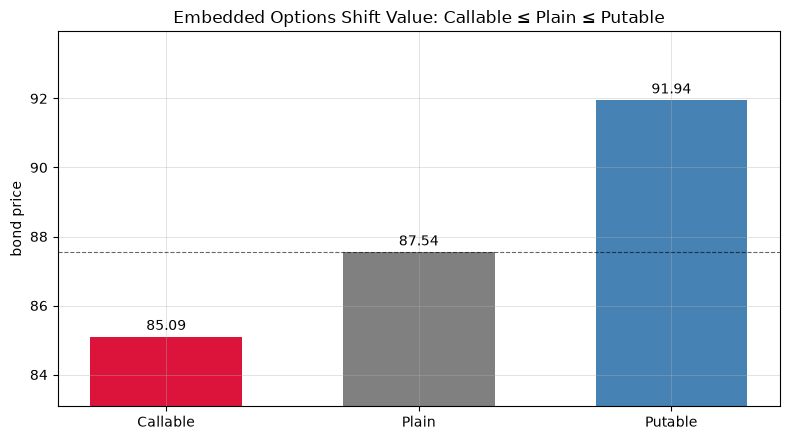

In [6]:
# Visualize how the embedded option shifts the bond's value.
labels = ["Callable", "Plain", "Putable"]
prices = [callable_price, plain, putable_price]
colors = ["crimson", "gray", "steelblue"]

fig, ax = plt.subplots()
bars = ax.bar(labels, prices, color=colors, width=0.6)

# Reference line at the plain-bond price to show the option's effect.
ax.axhline(plain, color="black", lw=0.8, linestyle="--", alpha=0.6)

# Annotate each bar with its price.
for bar, price in zip(bars, prices):
    ax.annotate(f"{price:.2f}",
                (bar.get_x() + bar.get_width() / 2, price),
                textcoords="offset points", xytext=(0, 5),
                ha="center", fontsize=10)

ax.set_ylabel("bond price")
ax.set_title("Embedded Options Shift Value: Callable ≤ Plain ≤ Putable")
# Zoom the y-axis to make the differences visible.
ax.set_ylim(min(prices) - 2, max(prices) + 2)

plt.tight_layout()
plt.show()

---

## Summary

A recombining binomial tree models rate uncertainty in `O(n²)` nodes, and backward induction prices any bond by folding expected, discounted values back to today. For plain bonds this merely reproduces deterministic discounting — but for **callable** and **putable** bonds, the per-node `min`/`max` exercise decision captures value that deterministic discounting cannot see. That is the whole reason the tree exists: optionality is path-dependent, and the tree makes the dependence explicit.

重合二叉樹以 `O(n²)` 個節點建模利率不確定性,後序回推透過將期望且折現後的價值折疊回今日,為任何債券定價。對普通債券,這只是重現確定性折現——但對**可贖回**與**可回售**債券,每節點的 `min`/`max` 行使決策捕捉了確定性折現看不見的價值。這正是利率樹存在的全部理由:選擇權是路徑相依的,而樹讓這個相依性變得明確。